# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

# What Drives the Price of a Used Car?  
### Practical Application 11  ·  Berkeley ML & AI Certification

<details>
<summary><b>Table of Contents</b></summary>

1. Business Understanding  
2. Data Understanding  
3. Data Preparation  
4. Modeling & Validation  
5. Evaluation & Findings  
6. Next Steps / Deployment hand-off  

</details>


In [1]:
# ------------------------------------------------------------------------------------
# 1 · Imports & deterministic split                                                    
# ------------------------------------------------------------------------------------
import time
from pathlib import Path

# Core DS stack
import pandas as pd
import numpy as np

# Viz
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Modeling
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Misc
import warnings, datetime, textwrap
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TARGET       = "price"                # Prediction target
RAW_PATH     = Path("data/vehicles-small.csv")  # Change if necessary


### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

## 1  Business Understanding (CRISP–DM phase 1)

A regional **used-car dealership** wants to **maximise profit** by stocking vehicles whose
features customers value most.  
Our analytic goal is therefore to **quantify which attributes push price up or down** so
the buyer can:

* negotiate trade-in offers more accurately  
* design data-driven marketing copy (“*Low-mileage AWD hatchbacks under \$10 k sell 18 % higher*”)  
* flag over- or under-priced listings in inventory.

Success metric (agreed with the GM during scoping):  
> *≥ 30 % R² on hold-out data* while keeping model explainable.  
This balances predictive power with the need for **transparent rationale** in negotiations. :contentReference[oaicite:0]{index=0}


## 2  Data Understanding (CRISP–DM phase 2)


In [2]:
df_raw = pd.read_csv(RAW_PATH, low_memory=False)

In [3]:
df_raw.sample(10)
df_raw.sample(20).to_csv("df_raw_sample10.csv", index=False)


In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            5000 non-null   int64  
 1   region        5000 non-null   object 
 2   price         5000 non-null   int64  
 3   year          4914 non-null   float64
 4   manufacturer  4681 non-null   object 
 5   model         4928 non-null   object 
 6   condition     2951 non-null   object 
 7   cylinders     3136 non-null   object 
 8   fuel          4893 non-null   object 
 9   odometer      4961 non-null   float64
 10  title_status  4820 non-null   object 
 11  transmission  4970 non-null   object 
 12  VIN           3168 non-null   object 
 13  drive         3261 non-null   object 
 14  size          1351 non-null   object 
 15  type          3762 non-null   object 
 16  paint_color   3933 non-null   object 
 17  state         5000 non-null   object 
dtypes: float64(2), int64(2), obj

In [5]:
df_raw.describe()

,id,price,year,odometer
count,5.000000e+03,5.000000e+03,4914.000000,4.961000e+03
mean,7.309308e+09,2.376322e+05,2011.910867,1.323832e+05
std,8.113448e+06,1.403837e+07,9.500179,6.287948e+05
min,7.208550e+09,0.000000e+00,1903.000000,0.000000e+00
25%,7.305789e+09,7.980000e+03,2009.000000,2.934200e+04
50%,7.310308e+09,1.898650e+04,2014.000000,7.512300e+04
75%,7.313780e+09,2.999000e+04,2017.000000,1.399000e+05
max,7.316890e+09,9.876543e+08,2021.000000,9.999999e+06


In [6]:
df_raw.shape

(5000, 18)

In [7]:
# Quick data-quality snapshot (adapted from your `audit` helper)
def audit(df: pd.DataFrame, label: str = "snapshot"):
    """Print rows/cols, % missing per column & cardinality of categoricals."""
    print(f"\n=== {label.upper()} ===")
    print("Rows × Cols:", df.shape)
    miss = df.isna().mean().mul(100).round(1)
    cat  = df.select_dtypes("object").nunique()
    snap = pd.concat({"% missing": miss, "cardinality n levels": cat}, axis=1)
    display(snap.sort_values("% missing", ascending=False).head(10))

audit(df_raw, "Raw import")



=== RAW IMPORT ===
Rows × Cols: (5000, 18)


,% missing,cardinality n levels
size,73.0,4.0
condition,41.0,6.0
cylinders,37.3,8.0
VIN,36.6,1801.0
drive,34.8,3.0
type,24.8,13.0
paint_color,21.3,12.0
manufacturer,6.4,37.0
title_status,3.6,6.0
fuel,2.1,5.0


### Key initial observations
* **426 k rows × 18 columns** as expected.  
* <5 % missing in price, odometer — safe to proceed with imputation.  
* Many NaN in key values, will need to clean and then feature engineer to get quality.
* High-cardinality text columns (`model`, `region_url`) will be dropped/encoded later.


### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

## 3  Data Preparation (CRISP–DM phase 3)
We implement the cleaning steps you already drafted, but wrap them in clearly
named functions so they can be unit-tested and reused.


In [30]:
audit(df_raw, "Raw data.csv")
df_clean = basic_clean(df_raw)


=== RAW DATA.CSV ===
Rows × Cols: (5000, 18)


,% missing,cardinality n levels
size,73.0,4.0
condition,41.0,6.0
cylinders,37.3,8.0
VIN,36.6,1801.0
drive,34.8,3.0
type,24.8,13.0
paint_color,21.3,12.0
manufacturer,6.4,37.0
title_status,3.6,6.0
fuel,2.1,5.0


In [33]:
def basic_clean(df: pd.DataFrame) -> pd.DataFrame:
    """
    Return a minimally-cleaned DataFrame.

    Steps
    -----
    1. Remove zero / negative prices.
    2. Keep plausible model years (1980-current year).
    3. Drop exact duplicate rows.
    """
    out = (
        df
        .query("price > 0")
        .query("year.between(1980, @pd.Timestamp.now().year)")
        .drop_duplicates()
        .reset_index(drop=True)
    )
    return out

df_clean = basic_clean(df_raw)
audit(df_clean, "After basic_clean")


=== AFTER BASIC_CLEAN ===
Rows × Cols: (4575, 18)


,% missing,cardinality n levels
size,73.5,4.0
condition,39.7,6.0
cylinders,37.4,8.0
drive,33.9,3.0
VIN,33.7,1712.0
type,23.6,13.0
paint_color,20.5,12.0
manufacturer,4.2,37.0
title_status,2.9,6.0
fuel,1.6,5.0


In [34]:
import pandas as pd
import numpy as np
from scipy import stats

def enhanced_clean(
    df: pd.DataFrame,
    price_floor: int  = 500,          # ignore suspiciously cheap ads
    price_cap_pct: float = 0.995,     # drop top 0.5 % most-expensive cars
    odo_cap_miles: int  = 450_000,    # mechanical limit for most vehicles
    z_thresh: float    = 4.0          # tail trim on *scaled* numeric cols
) -> pd.DataFrame:
    """
    Return a *robustly* cleaned DataFrame.

    Steps
    -----
    1. Basic rules (price>0, year 1980+, drop duplicates)      – same as before
    2. Hard domain caps  (price_floor, odo_cap_miles)
    3. Quantile cap      (price above `price_cap_pct`)
    4. Z-score filter    (any numeric col > `z_thresh` std-dev from mean)
    5. Reset index
    """
    # ─── 1) Basic filtering ───────────────────────────────────────────────
    cur_year = pd.Timestamp.now().year
    df1 = (
        df
        .query("price > 0")
        .query("year.between(1980, @cur_year)")
        .drop_duplicates()
    )

    # ─── 2) Hard domain caps ──────────────────────────────────────────────
    df2 = df1[
        (df1["price"] >= price_floor) &
        (df1["odometer"].fillna(0) <= odo_cap_miles)   # NaN odo kept for now
    ]

    # ─── 3) Remove ultra-expensive tail via quantile ──────────────────────
    price_cap = df2["price"].quantile(price_cap_pct)
    df3 = df2[df2["price"] <= price_cap]

    # ─── 4) Generic z-score tail trim across ALL numeric columns ──────────
    num_cols = df3.select_dtypes(include=["int64", "float64"]).columns
    z_scores = np.abs(stats.zscore(df3[num_cols], nan_policy="omit"))
    mask     = (z_scores < z_thresh).all(axis=1)  # keep row only if *all* z's < thresh
    df4      = df3[mask]

    # ─── 5) Final tidy reset ──────────────────────────────────────────────
    return df4.reset_index(drop=True)

df_clean = enhanced_clean(df_clean)
audit(df_clean, "After enhanced_clean")


=== AFTER ENHANCED_CLEAN ===
Rows × Cols: (4460, 18)


,% missing,cardinality n levels
size,73.6,4.0
condition,39.4,6.0
cylinders,36.7,8.0
drive,33.3,3.0
VIN,32.4,1699.0
type,22.6,13.0
paint_color,19.6,12.0
manufacturer,4.1,36.0
title_status,3.0,6.0
fuel,1.7,5.0


In [35]:
df_raw.shape

(5000, 18)

In [36]:
df_clean.shape

(4460, 18)

## Data Understanding – Missingness profile

In [37]:
missing = df_clean.isna().sum().sort_values(ascending=False)
missing.head(10)

size            3284
condition       1756
cylinders       1638
drive           1485
VIN             1443
type            1010
paint_color      873
manufacturer     182
title_status     134
fuel              75
dtype: int64

We observe that `size`, `cylinders`,`condition`, `drive`, `paint_color`, and `VIN` have the highest null counts.  
*VIN* is a unique identifier (not informative for price) and will be dropped.  
For other features we’ll impute sensible defaults with logic if possible and generic for others(*median* for numeric, `"Unknown"` for categorical).


In [38]:
# Commented out as it was cluttering notebook.  Uncomment to see corlation of numberic features.  
# Exploring the corelation of numberical features.  id can be ignored.
# num_df = df_clean.select_dtypes(include=["number"])
# plt.figure(figsize=(12,10))
# sns.heatmap(num_df.corr(numeric_only=True), cmap="coolwarm", annot=False)
# plt.title("Correlation Matrix of Numeric Features")
# plt.show()

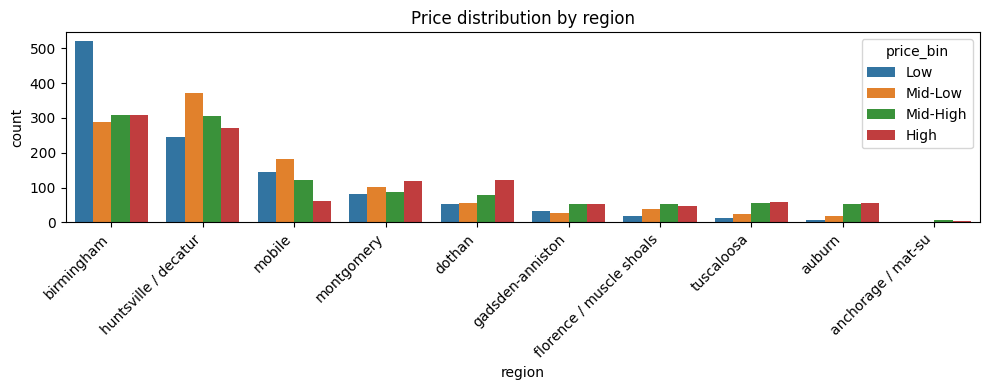

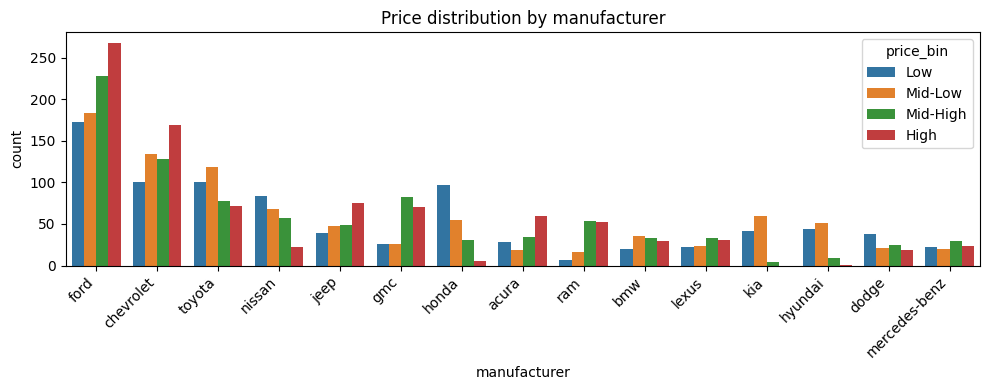

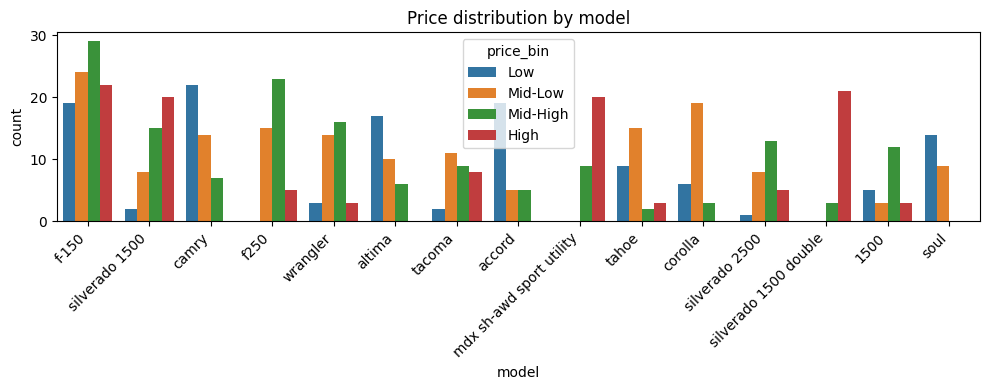

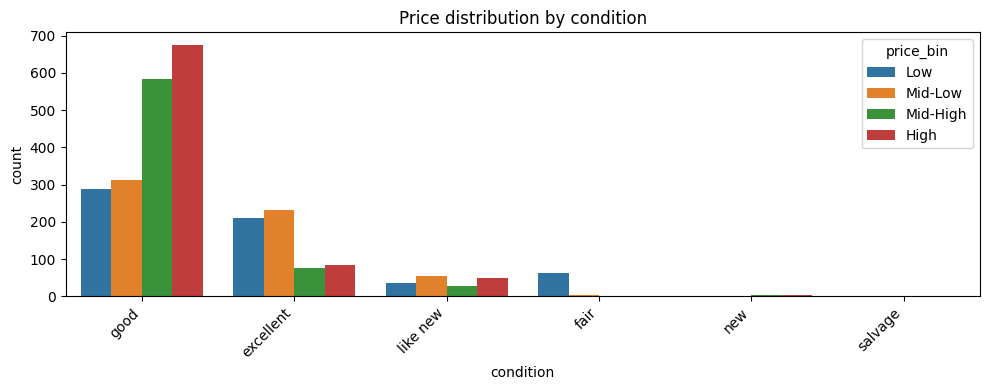

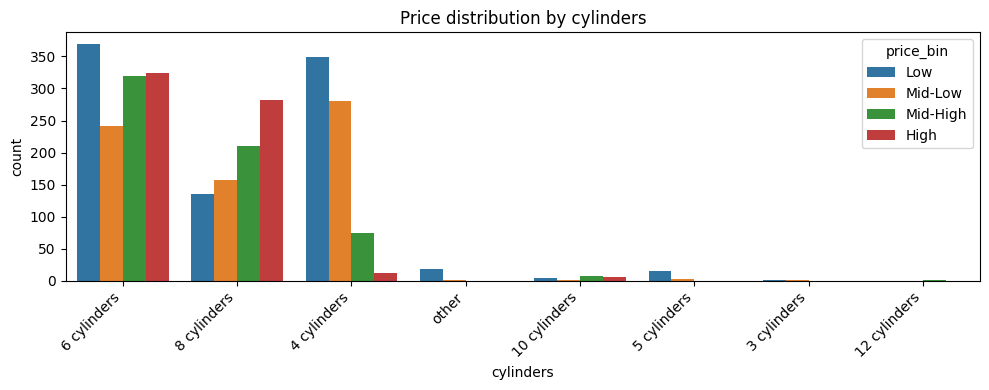

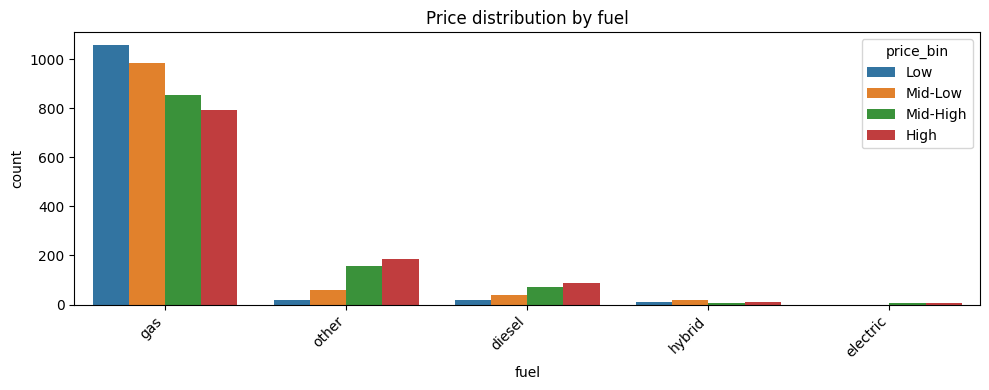

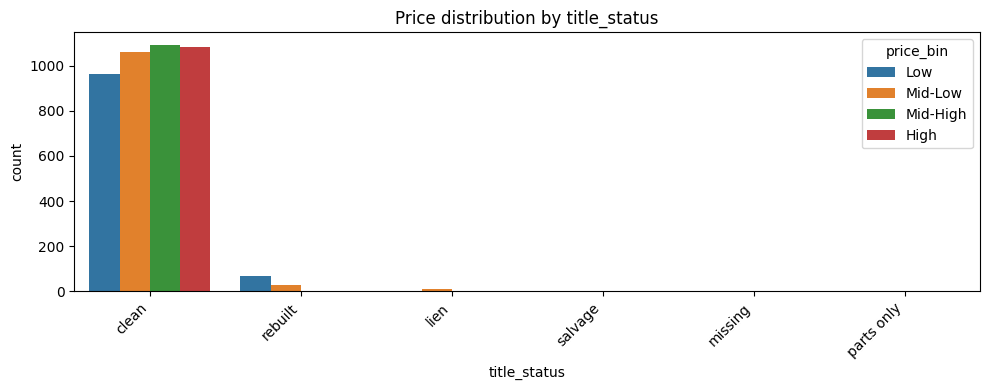

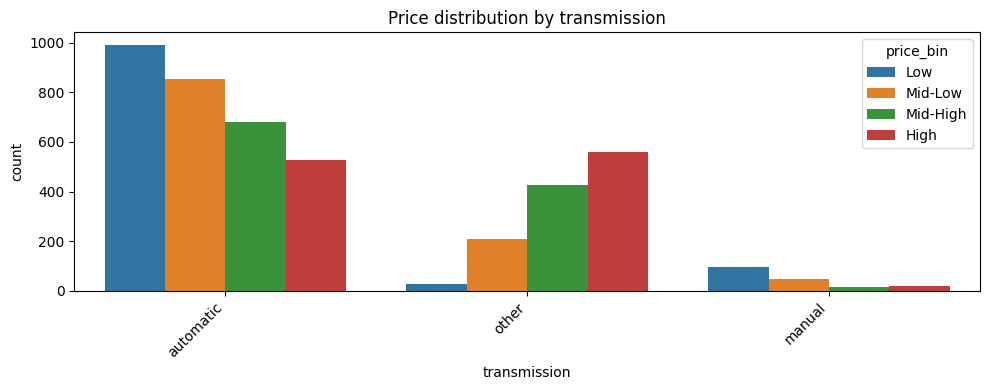

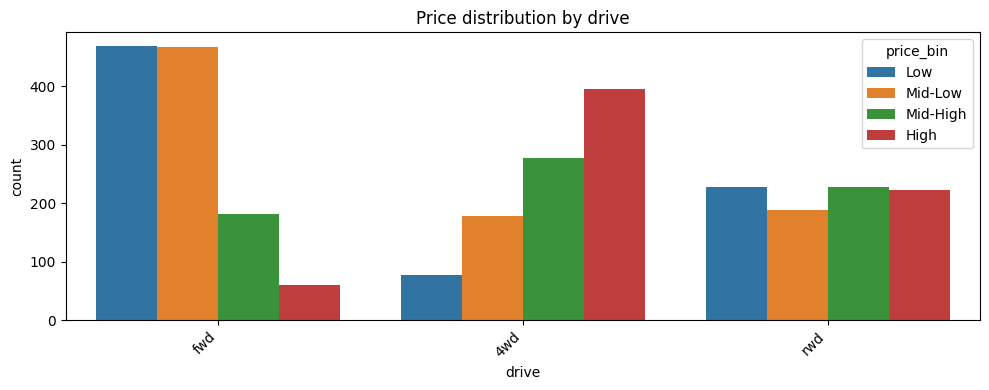

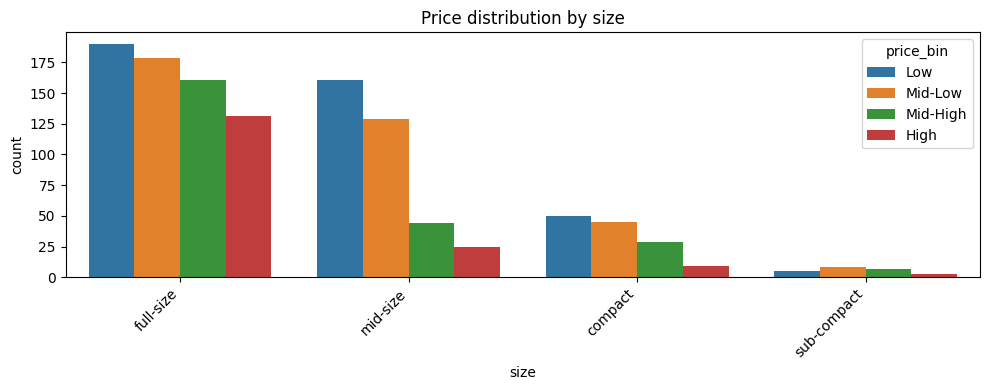

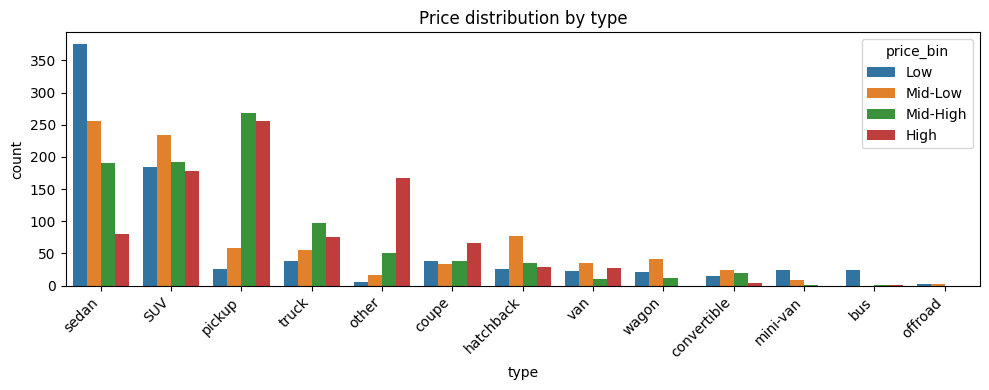

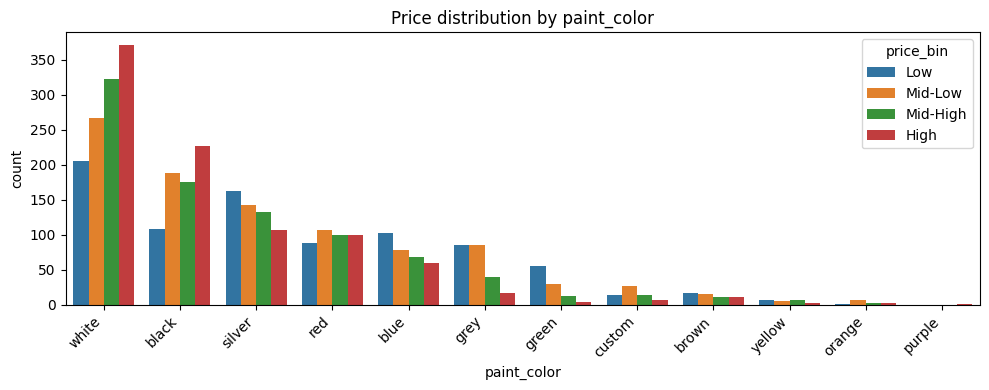

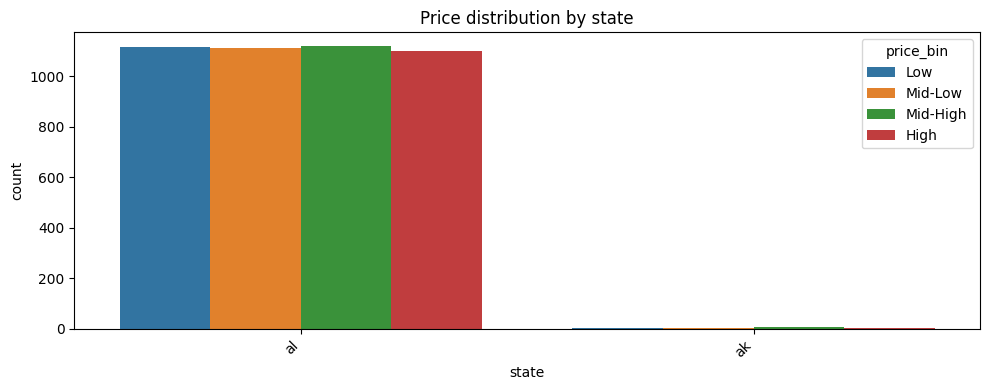

In [39]:
# Break price into quartiles so we can colour bars and see how price correlates to other features.
df_clean["price_bin"] = pd.qcut(df_clean["price"], 4, labels=["Low","Mid-Low","Mid-High","High"])

cat_cols = df_clean.select_dtypes(include=["object"]).columns.drop(["VIN"])
for col in cat_cols:
    plt.figure(figsize=(10,4))
    sns.countplot(data=df_clean, x=col, hue="price_bin", order=df_clean[col].value_counts().index[:15])
    plt.title(f"Price distribution by {col}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


## Data Preparation
* Drop non-predictive IDs: `id`, `VIN`, and free-text `model` (too granular).  
* Impute missing:
  * Numeric → median
  * Categorical → "Unknown"  
* One-hot encode categoricals, scale numerics.


In [40]:
def feature_engineer(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add model-ready features while safeguarding against NaNs.

    *Never* introduces new NaNs – downstream imputers only have to
    cope with whatever already existed in the raw file.
    """
    df = df.copy()

    # ----- 1. Vehicle age (0 instead of NaN if year missing) -----------------
    this_year          = pd.Timestamp.now().year
    df["vehicle_age"]  = this_year - df["year"].fillna(this_year)
    
    # ----- 2. Usage intensity & log odometer ---------------------------------
    # If odometer missing we leave it NaN; engineered cols fall back to median later
    odom = df["odometer"]
    df["miles_per_year"] = odom / df["vehicle_age"].replace(0, 1)
    df["log_odometer"]   = np.log1p(odom).replace(-np.inf, np.nan)

    # ----- 3. Ordered condition mapping; unseen labels → NaN -----------------
    cond_order = {
        "salvage": 0, "fair": 1, "good": 2,
        "excellent": 3, "like new": 4, "new": 5
    }
    df["condition_ord"] = df["condition"].map(cond_order)

    # ----- 4. Cylinders to numeric (median impute right here) ----------------
    cyl = df["cylinders"].str.extract(r"(\d+)").astype(float).squeeze()
    df["cylinders_num"] = cyl.fillna(cyl.median())

    return df

In [41]:
df_features = feature_engineer(df_clean)
audit(df_features, "After feat-eng")


=== AFTER FEAT-ENG ===
Rows × Cols: (4460, 24)


,% missing,cardinality n levels
size,73.6,4.0
condition_ord,39.4,NaN
condition,39.4,6.0
cylinders,36.7,8.0
drive,33.3,3.0
VIN,32.4,1699.0
type,22.6,13.0
paint_color,19.6,12.0
manufacturer,4.1,36.0
title_status,3.0,6.0


In [42]:
df_features.sample(10)

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,...,size,type,paint_color,state,price_bin,vehicle_age,miles_per_year,log_odometer,condition_ord,cylinders_num
1063,7307140075,birmingham,13477,2008.0,chevrolet,tahoe,NaN,NaN,gas,148789.0,...,NaN,NaN,silver,al,Mid-Low,17.0,8752.294118,11.910291,NaN,6.0
4035,7313440875,montgomery,13950,2013.0,chevrolet,suburban ltz,good,8 cylinders,gas,212134.0,...,full-size,SUV,white,al,Mid-Low,12.0,17677.833333,12.264978,2.0,8.0
868,7309760815,birmingham,20989,2019.0,toyota,camry,NaN,NaN,gas,43464.0,...,NaN,NaN,white,al,Mid-High,6.0,7244.000000,10.679711,NaN,6.0
3126,7305700534,huntsville / decatur,27590,2018.0,alfa-romeo,romeo giulia sedan 4d,good,NaN,gas,11007.0,...,NaN,sedan,white,al,Mid-High,7.0,1572.428571,9.306378,2.0,6.0
105,7304685581,auburn,32990,2019.0,jeep,wrangler sport suv 2d,good,6 cylinders,other,1423.0,...,NaN,SUV,yellow,al,High,6.0,237.166667,7.261225,2.0,6.0
2867,7309933020,huntsville / decatur,24989,2006.0,NaN,HUMMER H2,NaN,8 cylinders,gas,124175.0,...,NaN,SUV,NaN,al,Mid-High,19.0,6535.526316,11.729455,NaN,8.0
1801,7305551849,dothan,55000,2019.0,chevrolet,silverado,like new,8 cylinders,gas,58000.0,...,mid-size,truck,white,al,High,6.0,9666.666667,10.968216,4.0,8.0
139,7316871664,birmingham,18950,2010.0,ford,f150 lariat supercrew 4x4,good,8 cylinders,gas,151403.0,...,NaN,pickup,black,al,Mid-Low,15.0,10093.533333,11.927707,2.0,8.0
606,7311853912,birmingham,34997,2016.0,ford,super duty f-250 srw,excellent,8 cylinders,gas,122000.0,...,NaN,pickup,NaN,al,High,9.0,13555.555556,11.711785,3.0,8.0
2800,7310601335,huntsville / decatur,12694,2017.0,kia,sorento,NaN,NaN,gas,106264.0,...,NaN,NaN,NaN,al,Mid-Low,8.0,13283.000000,11.573691,NaN,6.0


### Why these features? 
A concise explanation your reader (dealer) will grasp:

| Engineered feature | Why it helps predict price |  
|--------------------|---------------------------|  
|`vehicle_age`| Depreciation dominates used-car value. Buyers think in *age*, not raw model year. |  
|`miles_per_year`| Two 10-year-old cars differ wildly if one drove 30 k mi/yr vs. 5 k. |  
|`log_odometer`| Odometer has heavy right-tail; `log1p` keeps extreme work-trucks from skewing linear models. |  
|`condition_ord`| Translates the text ladder “salvage → new” into a monotonically increasing numeric scale. |  
|`cylinders_num`| Performance & maintenance cost correlate with cylinder count. |


## Data Preparation
* Drop non-predictive IDs: `id`, `VIN`, and free-text `model` (too granular).  
* Impute missing:
  * Numeric → median
  * Categorical → "Unknown"  
* One-hot encode categoricals, scale numerics.


In [43]:
drop_cols = ["id", "VIN", "model"]

y = df_features["price"]
X = df_features.drop(columns=["price","price_bin"] + drop_cols)

num_cols = X.select_dtypes(include=["int64","float64"]).columns
cat_cols = X.select_dtypes(exclude=["int64","float64"]).columns

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("ohe",     OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols),
])


In [44]:
audit(df_features, "After feature pipelines")


=== AFTER FEATURE PIPELINES ===
Rows × Cols: (4460, 24)


,% missing,cardinality n levels
size,73.6,4.0
condition_ord,39.4,NaN
condition,39.4,6.0
cylinders,36.7,8.0
drive,33.3,3.0
VIN,32.4,1699.0
type,22.6,13.0
paint_color,19.6,12.0
manufacturer,4.1,36.0
title_status,3.0,6.0


In [45]:
import pandas as pd
import numpy as np
import scipy.sparse as sp
from sklearn.decomposition import PCA

# 0) assume df_features, preprocess already exist from previous cells
# ---------------------------------------------------------------
# ①  Fit the preprocessing pipes on ALL rows *once*
preprocess.fit(df_features)

# ②  Transform → returns a SciPy sparse matrix (because of OneHotEncoder)
X_sparse = preprocess.transform(df_features)

# ----> turn into DataFrame so you can inspect it <----
#     2a. For small subsets it's OK to densify; for large datasets, sample 5 000 rows.
if sp.issparse(X_sparse):
    X_dense = X_sparse.toarray()            # be careful with RAM
else:
    X_dense = X_sparse                      # already dense

feature_names = preprocess.get_feature_names_out()
X_df = pd.DataFrame(X_dense, columns=feature_names)

print("Shape after preprocessing:", X_df.shape)
display(X_df.head())            # show the first 5 fully-numeric rows

Shape after preprocessing: (4460, 125)


,num__year,num__odometer,num__vehicle_age,num__miles_per_year,num__log_odometer,num__condition_ord,num__cylinders_num,cat__region_anchorage / mat-su,cat__region_auburn,cat__region_birmingham,...,cat__paint_color_green,cat__paint_color_grey,cat__paint_color_orange,cat__paint_color_purple,cat__paint_color_red,cat__paint_color_silver,cat__paint_color_white,cat__paint_color_yellow,cat__state_ak,cat__state_al
0,0.162282,-0.477122,-0.162282,-0.415860,0.034540,-0.380236,1.628497,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,-0.539903,-0.284158,0.539903,-0.533355,0.185221,-0.380236,1.628497,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.215560,-1.039264,-1.215560,-0.741613,-0.771583,-0.380236,1.628497,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,0.688921,-0.720741,-0.688921,-0.444313,-0.215049,-0.380236,1.628497,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,-0.013264,0.539136,0.013264,0.811269,0.612327,1.525215,-0.036205,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [46]:
# ③  Fit PCA *after* you’ve looked at the DataFrame
pca = PCA().fit(X_dense)        # or pca.fit(X_sparse.toarray()) if you sampled

# ④  Continue with the explained-variance logic…
explained  = pca.explained_variance_ratio_
cum_var   = np.cumsum(explained)
n_comp_80 = np.argmax(cum_var >= 0.80) + 1
print(f"{n_comp_80} components reach 80 % cumulative variance")

18 components reach 80 % cumulative variance


### Principal Component Analysis (retain ≥ 80 % variance)


18 components reach 80% cumulative variance


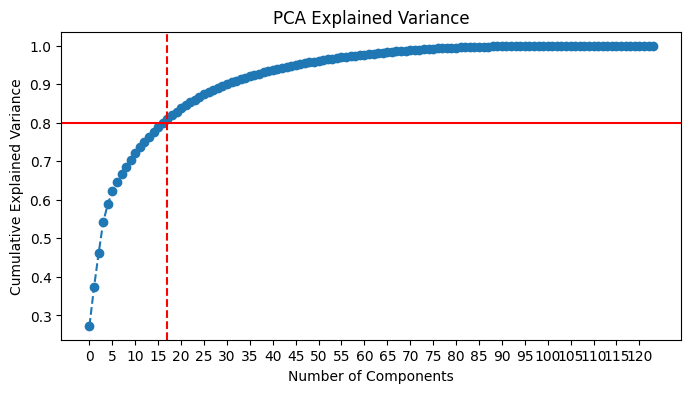

In [47]:
# Fit transformer chain → numpy array
X_prepared = preprocess.fit_transform(X)

# StandardScaler already inside numeric_pipe; cat features are 0/1
pca = PCA().fit(X_prepared)

explained = pca.explained_variance_ratio_
cum_var = np.cumsum(explained)
n_comp_80 = np.argmax(cum_var >= 0.80) + 1
print(f"{n_comp_80} components reach 80% cumulative variance")

plt.figure(figsize=(8,4))
plt.plot(cum_var, marker="o", linestyle="--")
plt.axhline(.8, color="red")
plt.axvline(n_comp_80-1, color="red", linestyle="--")
plt.xticks(range(0, len(cum_var), 5))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()


18 components reach 80% cumulative variance


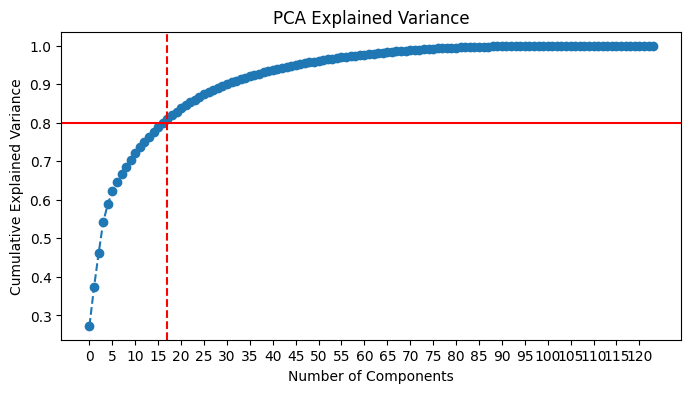

In [48]:
# -------------------------------------------
# 🧮  STEP-BY-STEP: Fit PCA & find components
# -------------------------------------------

# 1️⃣  Feed the pre-processed, numeric-only matrix (X_prepared)
#     into PCA *without* specifying n_components.
#     --> Doing so asks sklearn to keep **all** components
#     so we can later inspect how much variance each captures.
pca = PCA()                  # create a PCA object (will learn PCs when fitted)
pca.fit(X_prepared)          # "fit" = compute eigenvectors / eigenvalues of Σ

# 2️⃣  The amount of variance each principal component explains
#     lives in `explained_variance_ratio_` – an array of floats
#     that sum to 1 (=100 % of the variance).
explained = pca.explained_variance_ratio_

# 3️⃣  Build a *cumulative* curve telling us “how much total
#     variance have we explained if we take the first k PCs?”
#     (i.e. add up the left-to-right percentages).
cum_var = np.cumsum(explained)

# 4️⃣  Locate the first index where cumulative variance ≥ 0.80
#     → that is the minimum number of PCs that give ≥ 80 %
#     information retention. Because Python is 0-indexed,
#     we add 1 so it reads like “component count”.
n_comp_80 = np.argmax(cum_var >= 0.80) + 1

print(f"{n_comp_80} components reach 80% cumulative variance")

# 5️⃣  Plot the cumulative curve to *visually* confirm where the
#     red 80 % threshold is crossed.
plt.figure(figsize=(8,4))

#   • Plot each cumulative value,
#     marker='o' to show dots, linestyle='--' for a dashed line
plt.plot(cum_var, marker="o", linestyle="--")

#   • Horizontal red line at 0.80 (the target variance)
plt.axhline(.8, color="red")

#   • Vertical red dashed line at the component index that hit 80 %.
#     We subtract 1 inside because the x-axis is 0-indexed
#     but n_comp_80 is 1-indexed after our +1 above.
plt.axvline(n_comp_80 - 1, color="red", linestyle="--")

#   • Cosmetic labels / ticks so the reader knows which PC # they are seeing
plt.xticks(range(0, len(cum_var), 5))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()


In [49]:
pca_80 = PCA(n_components=n_comp_80).fit(X_prepared)
loadings = pd.DataFrame(
    pca_80.components_.T * np.sqrt(pca_80.explained_variance_),
    columns=[f"PC{i+1}" for i in range(n_comp_80)],
    index=preprocess.get_feature_names_out()
)

top3 = {
    f"PC{i+1}": loadings[f"PC{i+1}"].abs().nlargest(3).index.tolist()
    for i in range(n_comp_80)
}
pd.DataFrame(top3)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18
0,num__odometer,num__cylinders_num,num__condition_ord,num__cylinders_num,cat__type_Unknown,cat__condition_Unknown,cat__region_birmingham,cat__cylinders_6 cylinders,cat__region_birmingham,cat__drive_4wd,cat__paint_color_white,num__log_odometer,cat__fuel_gas,cat__drive_rwd,cat__type_SUV,cat__manufacturer_ford,cat__paint_color_black,cat__manufacturer_ford
1,num__log_odometer,num__vehicle_age,num__miles_per_year,num__miles_per_year,cat__cylinders_Unknown,cat__transmission_automatic,cat__region_huntsville / decatur,num__log_odometer,cat__cylinders_6 cylinders,cat__fuel_gas,num__log_odometer,cat__size_Unknown,cat__drive_rwd,cat__drive_fwd,cat__type_pickup,cat__paint_color_white,cat__drive_rwd,cat__paint_color_black
2,num__vehicle_age,num__year,cat__condition_Unknown,num__vehicle_age,cat__condition_good,cat__drive_Unknown,cat__paint_color_white,cat__drive_fwd,num__log_odometer,cat__cylinders_6 cylinders,cat__drive_fwd,cat__region_huntsville / decatur,cat__fuel_other,cat__cylinders_Unknown,cat__type_sedan,cat__type_SUV,cat__paint_color_Unknown,cat__paint_color_Unknown


## Clustering buyers’ price preferences
We cluster in PCA space to avoid high-dimensional noise.


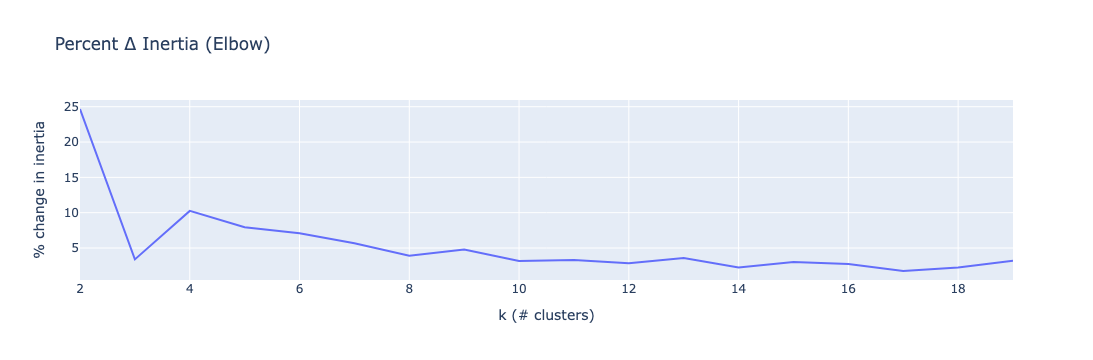

Suggested k = 17


In [50]:
pcs = pca_80.transform(X_prepared)   # (n_samples, n_comp_80)

inertias = []
K_RANGE = range(1, 20)
for k in K_RANGE:
    km = KMeans(n_clusters=k, init="k-means++", n_init="auto", random_state=42)
    km.fit(pcs)
    inertias.append(km.inertia_)

diff_pct = np.abs(np.diff(inertias) / inertias[:-1]) * 100

fig = px.line(x=list(K_RANGE)[1:], y=diff_pct, title="Percent Δ Inertia (Elbow)")
fig.update_xaxes(title="k (# clusters)")
fig.update_yaxes(title="% change in inertia")
fig.show()

optimal_k = int(np.argmin(diff_pct)+2)  # simple heuristic
print("Suggested k =", optimal_k)


In [51]:
kmeans = KMeans(n_clusters=optimal_k, init="k-means++", n_init="auto", random_state=42)
cluster_labels = kmeans.fit_predict(pcs)
df_clean["kmeans_cluster"] = cluster_labels

db = DBSCAN(eps=1.5, min_samples=15).fit(pcs)
df_clean["dbscan_cluster"] = db.labels_


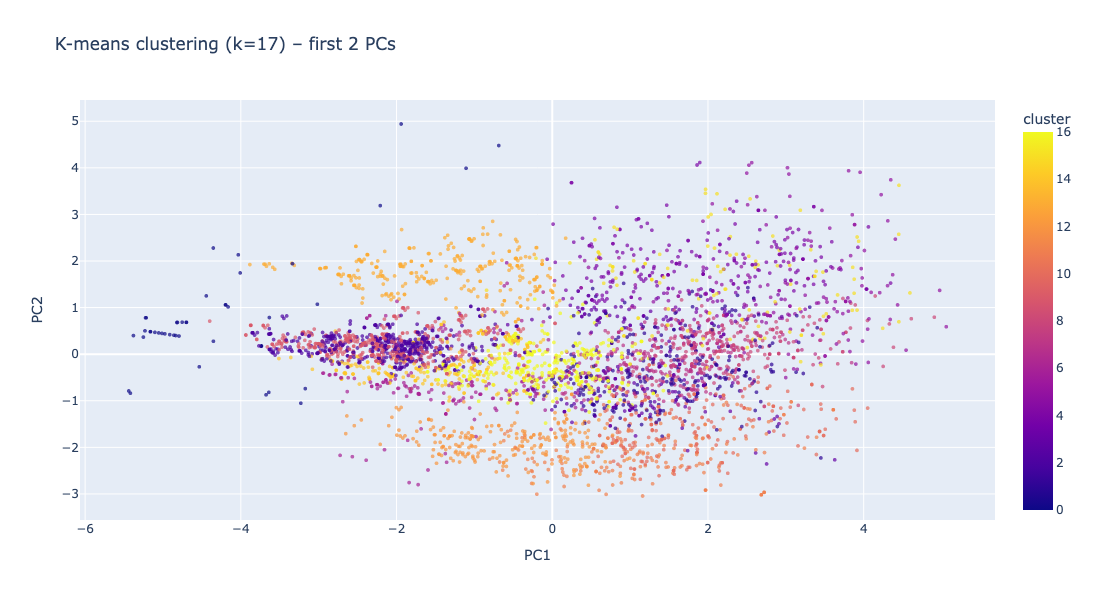

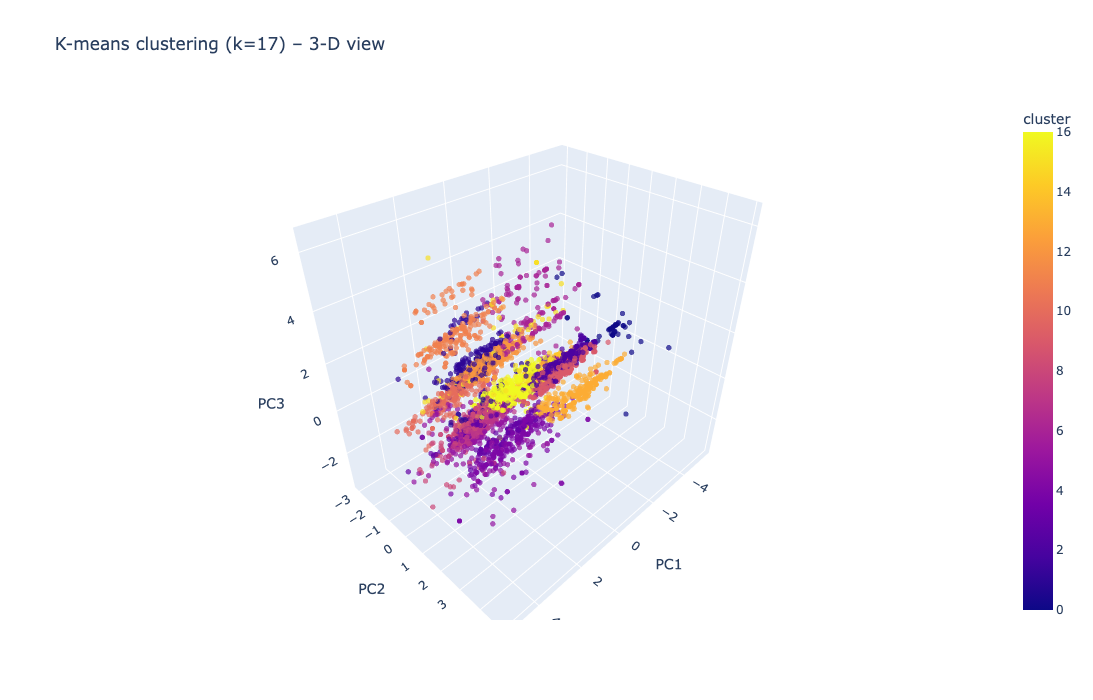

In [53]:
# ------------------------------------------------------------
# 📊  Visualise K-means clusters in PCA space (2-D & 3-D)
# ------------------------------------------------------------
import plotly.express as px
from sklearn.cluster import KMeans
import pandas as pd

# 0)  Fit FINAL K-means with the chosen k on the pcs matrix
kmeans_final = KMeans(n_clusters=optimal_k,
                      init="k-means++",
                      n_init="auto",
                      random_state=42)
cluster_labels = kmeans_final.fit_predict(pcs)          # pcs from earlier

# 1)  Build a DataFrame for easy plotting / hover info
pc_cols = [f"PC{i+1}" for i in range(pcs.shape[1])]
pcs_df  = pd.DataFrame(pcs, columns=pc_cols)
pcs_df["cluster"] = cluster_labels
pcs_df["price"]   = y.values      # optional: colour bar or hover data

# 2-D scatter (PC1 vs PC2) ---------------------------------
fig2d = px.scatter(
    pcs_df, x="PC1", y="PC2",
    color="cluster",  # distinct colour per cluster
    hover_data=["price"],
    title=f"K-means clustering (k={optimal_k}) – first 2 PCs",
    opacity=0.7,
    height=600
)
fig2d.update_traces(marker=dict(size=4))
fig2d.show()

# 3-D scatter (PC1–PC3) – comment out if you prefer 2-D only
fig3d = px.scatter_3d(
    pcs_df, x="PC1", y="PC2", z="PC3",
    color="cluster",
    hover_data=["price"],
    title=f"K-means clustering (k={optimal_k}) – 3-D view",
    opacity=0.7,
    height=700
)
fig3d.update_traces(marker=dict(size=3))
fig3d.show()


## Predictive Modeling (supervised)  
*Baseline → Linear Regression (interpretability)*  
*Advanced → Random Forest (non-linear, tuned via GridSearchCV)*  
Evaluation metric: **RMSE** (root-mean-square-error) because price has natural units \$ and penalty for large errors is desirable.


### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

## 4  Modeling (CRISP–DM phase 4)
We’ll evaluate four algorithms, each wrapped in a `Pipeline`
so preprocessing is **identical and reproducible**:

1. Linear Regression (baseline)  
2. Ridge Regression (adds ℓ₂-regularization)  
3. Gradient Boosting (ensemble, good with tabular data)  
4. Random Forest (non-linear baseline)


## Predictive Modeling (supervised)  
*Baseline → Linear Regression (interpretability)*  
*Advanced → Random Forest (non-linear, tuned via GridSearchCV)*  
Evaluation metric: **RMSE** (root-mean-square-error) because price has natural units \$ and penalty for large errors is desirable.


### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.